# 데이터 불러오기

In [1]:
# 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import nbformat
import json

import kiwipiepy
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from matplotlib_venn import venn2


# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 전처리 파일

In [2]:
# 데이터 로드
df_sale = pd.read_csv("reviews_merged.csv")
df_rec = pd.read_csv("recommend_reviews_merged.csv")

print(f"판매금액순 리뷰: {len(df_sale)}건")
print(f"추천순 리뷰: {len(df_rec)}건")

print(f"\n판매금액순 카테고리:\n{df_sale['category'].value_counts()}")
print(f"\n추천순 카테고리:\n{df_rec['category'].value_counts()}")

판매금액순 리뷰: 26913건
추천순 리뷰: 21252건

판매금액순 카테고리:
category
하의      11141
상의       7999
아우터      4900
액세서리     1919
스커트       717
가방        237
Name: count, dtype: int64

추천순 카테고리:
category
하의      16155
상의       3107
액세서리     1008
스커트       626
아우터       177
양말        112
언더웨어       60
드레스         7
Name: count, dtype: int64


In [3]:
# 공통 goods_no
overlap_goods = set(df_sale['goods_no']) & set(df_rec['goods_no'])
only_sale_goods = set(df_sale['goods_no']) - set(df_rec['goods_no'])
only_rec_goods = set(df_rec['goods_no']) - set(df_sale['goods_no'])

print(f"공통 상품 수: {len(overlap_goods)}개")
print(f"판매금액순에만 있는 상품 수: {len(only_sale_goods)}개")
print(f"추천순에만 있는 상품 수: {len(only_rec_goods)}개")

# 공통 상품 리뷰
overlap_reviews_sale = df_sale[df_sale['goods_no'].isin(overlap_goods)]
overlap_reviews_rec = df_rec[df_rec['goods_no'].isin(overlap_goods)]

print(f"\n=== 공통 15개 상품 ===")
print(f"판매금액순 수집 리뷰: {len(overlap_reviews_sale)}건")
print(f"추천순 수집 리뷰: {len(overlap_reviews_rec)}건")

# 공통 상품 목록 + 각각 리뷰 수
df_overlap_info = df_sale[df_sale['goods_no'].isin(overlap_goods)][['goods_no','goods_name']].drop_duplicates()
sale_cnt = overlap_reviews_sale.groupby('goods_no')['review_no'].count().rename('판매금액순_리뷰수')
rec_cnt = overlap_reviews_rec.groupby('goods_no')['review_no'].count().rename('추천순_리뷰수')
df_overlap_info = df_overlap_info.set_index('goods_no').join(sale_cnt).join(rec_cnt).reset_index()
print(f"\n공통 상품별 리뷰 수 비교:")
print(df_overlap_info.to_string())

# 판매금액순에만 있는 35개
only_sale_reviews = df_sale[df_sale['goods_no'].isin(only_sale_goods)]
print(f"\n=== 판매금액순에만 있는 35개 상품 ===")
print(f"리뷰 수: {len(only_sale_reviews)}건")

# 추천순에만 있는 35개
only_rec_reviews = df_rec[df_rec['goods_no'].isin(only_rec_goods)]
print(f"\n=== 추천순에만 있는 35개 상품 ===")
print(f"리뷰 수: {len(only_rec_reviews)}건")

공통 상품 수: 15개
판매금액순에만 있는 상품 수: 35개
추천순에만 있는 상품 수: 35개

=== 공통 15개 상품 ===
판매금액순 수집 리뷰: 7642건
추천순 수집 리뷰: 7978건

공통 상품별 리뷰 수 비교:
    goods_no                                         goods_name  판매금액순_리뷰수  추천순_리뷰수
0    6092190      [한소희 PICK] [UV 프로텍션] 우먼즈 시어 윈드브레이커 (5 colors)        133      146
1    6092187                [한소희 PICK] 우먼즈 코튼 커브드 팬츠 (3 colors)        364      389
2    3753637                   [한소희 PICK] 우먼즈 슬림 크루 넥 티셔츠 [화이트]        968     1000
3    2818150                                 우먼즈 와이드 카고 팬츠 [블랙]        980     1000
4    2978126                                  우먼즈 파라슈트 팬츠 [건메탈]        961      990
5    5166592                                우먼즈 커브드 치노 팬츠 [베이지]        167      174
6    5721297                              우먼즈 싱글 하프 트렌치 코트 [크림]         30       31
7    3445169                              우먼즈 신세틱 레더 슬림 벨트_20mm        970     1000
8    2820940             우먼즈 더블 니트 투 턱 와이드 라운지 스웨트 팬츠 [미디엄 그레이]        937     1000
9    5661619                       

## 클러스터 결과 파일

In [ ]:
# 노트북 파일 읽기
with open("무신사_판매금액순_리뷰분석.ipynb", "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# 각 셀의 출력값 확인
for i, cell in enumerate(nb.cells):
    if cell.cell_type == "code" and cell.outputs:
        print(f"=== Cell {i} ===")
        for output in cell.outputs:
            if "text" in output:
                print("".join(output["text"])[:500])
        print()

=== Cell 1 ===
👀 통합 데이터 상위 5개 확인


📊 데이터 요약 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26913 entries, 0 to 26912
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   goods_no       26913 non-null  int64  
 1   review_no      26913 non-null  int64  
 2   content        26913 non-null  object 
 3   grade          26913 non-null  int64  
 4   option_size    26913 non-null  object 
 5   size_feedback  7222 non-null   object 
 6   create_date    26913 

=== Cell 2 ===

=== Cell 3 ===
✨ 다이어트 완료된 데이터 구조:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26913 entries, 0 to 26912
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   goods_no       26913 non-null  int64  
 1   review_no      26913 non-null  int64  
 2   grade          26913 non-null  int64  
 3   size_feedback  7222 non-null   object 
 4   height         24115 non-null  float

In [5]:
df_cluster = pd.read_csv("musinsa_review_analysis.csv", encoding='utf-8-sig')

# 차트

## 가격대별 상품 분포

판매금액순 가격대 분포:
price_tier
저가 (~3만)     11
중가 (3~6만)    27
고가 (6만+)     12
Name: count, dtype: int64

추천순 가격대 분포:
price_tier
저가 (~3만)     13
중가 (3~6만)    35
고가 (6만+)      2
Name: count, dtype: int64


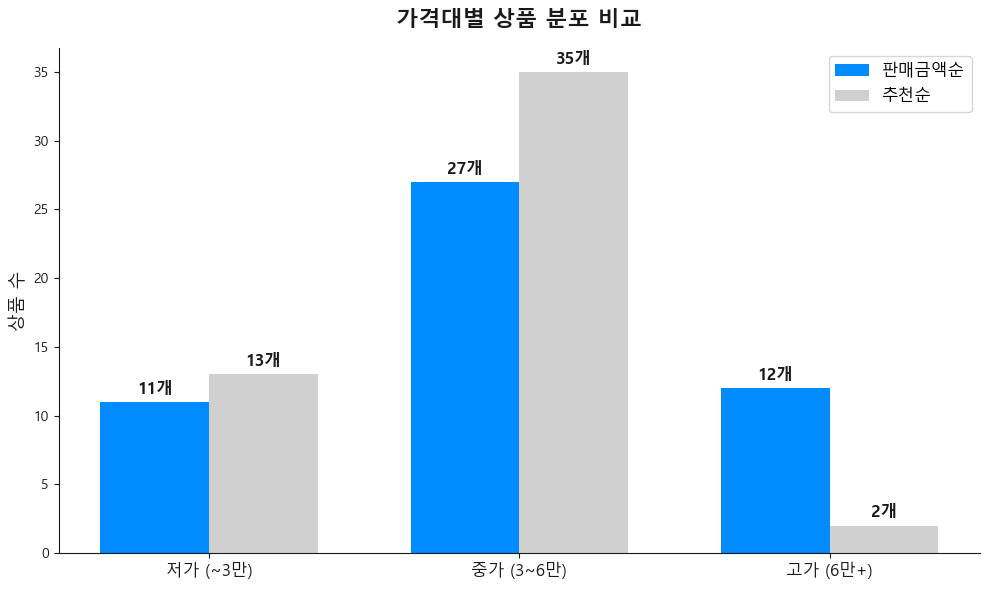

In [29]:
# 컬러 팔레트
BLUE   = '#008BFF'   # 일반 바 차트 기본색
BLACK  = '#1A1A1A'
WHITE  = '#FFFFFF'
GRAY   = '#D0D0D0'   # 보조색 (대비용)

# 세그먼트 비교용 4색
SEG_COLORS = {
    '검증 구매형': '#456B9D',
    '소재 목적형': '#36815E',
    '핏 기준형':   '#E63946',
    '경험 만족형': '#583981',
}

# 상품 단위 중복 제거
df_sale_top50 = df_sale[['goods_no', 'goods_name', 'sale_price']].drop_duplicates(subset='goods_no')
df_rec_top50 = df_rec[['goods_no', 'goods_name', 'sale_price']].drop_duplicates(subset='goods_no')

# 가격대 분류
def price_tier(price):
    if price < 30000:
        return '저가 (~3만)'
    elif price < 60000:
        return '중가 (3~6만)'
    else:
        return '고가 (6만+)'

df_sale_top50['price_tier'] = df_sale_top50['sale_price'].apply(price_tier)
df_rec_top50['price_tier'] = df_rec_top50['sale_price'].apply(price_tier)

order = ['저가 (~3만)', '중가 (3~6만)', '고가 (6만+)']
sale_tier = df_sale_top50['price_tier'].value_counts().reindex(order)
rec_tier = df_rec_top50['price_tier'].value_counts().reindex(order)

print("판매금액순 가격대 분포:")
print(sale_tier)
print("\n추천순 가격대 분포:")
print(rec_tier)

# 시각화
x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

bars1 = ax.bar(x - width/2, sale_tier, width, label='판매금액순', color=BLUE)
bars2 = ax.bar(x + width/2, rec_tier, width, label='추천순', color=GRAY)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{int(bar.get_height())}개', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color=BLACK)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{int(bar.get_height())}개', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color=BLACK)

ax.set_title('가격대별 상품 분포 비교', fontsize=16, fontweight='bold', pad=15, color=BLACK)
ax.set_ylabel('상품 수', fontsize=13, color=BLACK)
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=12, color=BLACK)
ax.tick_params(colors=BLACK)
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(BLACK)
ax.spines['bottom'].set_color(BLACK)

plt.tight_layout()
plt.show()

## 가격대별 리뷰 수 비교

판매금액순 가격대별 리뷰 수:
price_tier
저가 (~3만)      8971
중가 (3~6만)    15972
고가 (6만+)      1970
Name: count, dtype: int64

추천순 가격대별 리뷰 수:
price_tier
저가 (~3만)      4480
중가 (3~6만)    16734
고가 (6만+)        38
Name: count, dtype: int64


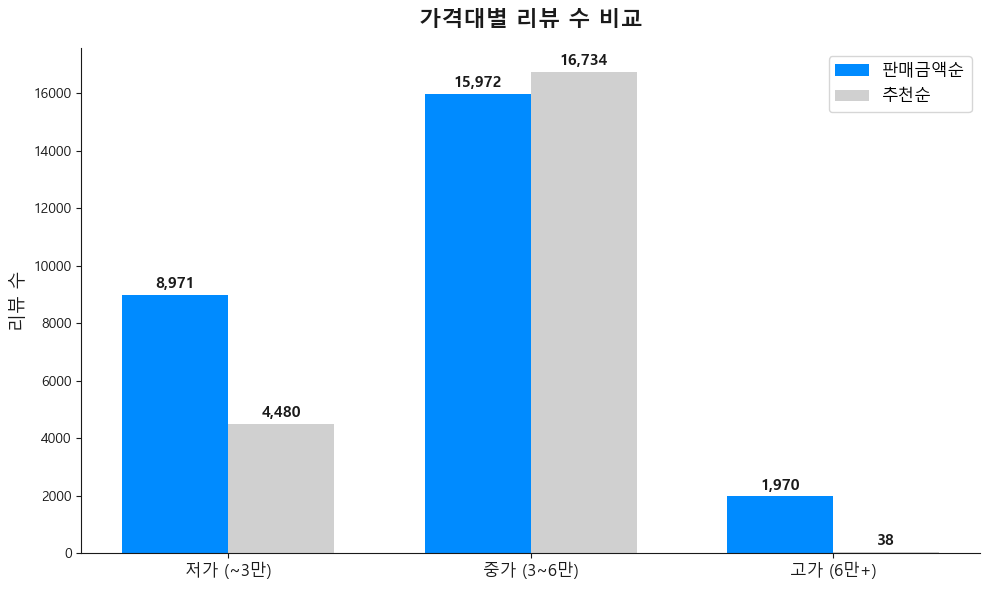

In [8]:
# 가격대 분류 컬럼 추가
def price_tier(price):
    if price < 30000:
        return '저가 (~3만)'
    elif price < 60000:
        return '중가 (3~6만)'
    else:
        return '고가 (6만+)'

df_sale['price_tier'] = df_sale['sale_price'].apply(price_tier)
df_rec['price_tier'] = df_rec['sale_price'].apply(price_tier)

order = ['저가 (~3만)', '중가 (3~6만)', '고가 (6만+)']
sale_review = df_sale['price_tier'].value_counts().reindex(order)
rec_review = df_rec['price_tier'].value_counts().reindex(order)

print("판매금액순 가격대별 리뷰 수:")
print(sale_review)
print("\n추천순 가격대별 리뷰 수:")
print(rec_review)

x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

bars1 = ax.bar(x - width/2, sale_review, width, label='판매금액순', color=BLUE)
bars2 = ax.bar(x + width/2, rec_review, width, label='추천순', color=GRAY)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=BLACK)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=BLACK)

ax.set_title('가격대별 리뷰 수 비교', fontsize=16, fontweight='bold', pad=15, color=BLACK)
ax.set_ylabel('리뷰 수', fontsize=13, color=BLACK)
ax.set_xticks(x)
ax.set_xticklabels(order, fontsize=12, color=BLACK)
ax.tick_params(colors=BLACK)
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(BLACK)
ax.spines['bottom'].set_color(BLACK)

plt.tight_layout()
plt.show()

In [27]:
# 상품 단위 중복 제거
goods = df_sale.groupby(['goods_no','goods_name','category','sale_price','review_count','review_score']).size().reset_index(name='_').drop(columns='_')

# 가격대 구간 분류
def price_band(price):
    if price < 20000:
        return '~2만'
    elif price < 30000:
        return '2~3만'
    elif price < 40000:
        return '3~4만'
    elif price < 50000:
        return '4~5만'
    elif price < 70000:
        return '5~7만'
    else:
        return '7만+'

goods['price_band'] = goods['sale_price'].apply(price_band)

band_order = ['~2만', '2~3만', '3~4만', '4~5만', '5~7만', '7만+']

# 구간별 통계
band_stats = goods.groupby('price_band')['review_count'].agg(
    평균=np.mean,
    중앙값=np.median,
    상품수='count'
).reindex(band_order).reset_index()

print(band_stats)

  price_band           평균     중앙값  상품수
0        ~2만  6615.888889  4687.0    9
1       2~3만  5450.500000  5450.5    2
2       3~4만  3657.400000  3053.0   10
3       4~5만  1480.500000   348.5   12
4       5~7만   773.875000    43.0    8
5        7만+   111.222222    48.0    9


C:\Users\User\AppData\Local\Temp\ipykernel_20772\251530561.py:24: FutureWarning: The provided callable <function mean at 0x000002A14E8AB380> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  band_stats = goods.groupby('price_band')['review_count'].agg(
C:\Users\User\AppData\Local\Temp\ipykernel_20772\251530561.py:24: FutureWarning: The provided callable <function median at 0x000002A14E9CDE40> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  band_stats = goods.groupby('price_band')['review_count'].agg(


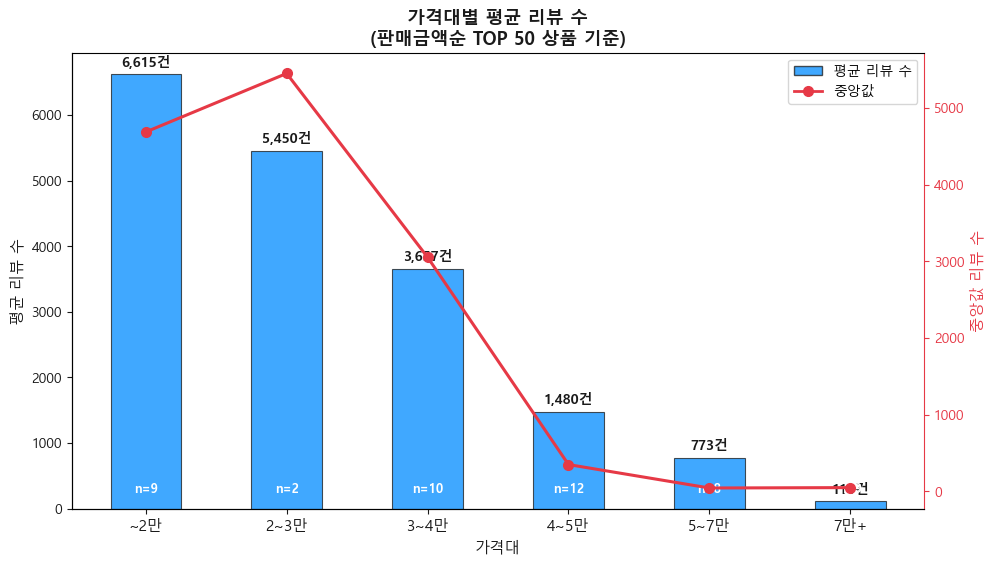

In [28]:
fig, ax1 = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(WHITE)
ax1.set_facecolor(WHITE)

x = np.arange(len(band_order))

# 막대: 평균 리뷰 수
bars = ax1.bar(x, band_stats['평균'], width=0.5,
               color=BLUE, alpha=0.75, edgecolor=BLACK, linewidth=0.8, zorder=2)

# 선: 중앙값
ax2 = ax1.twinx()
ax2.plot(x, band_stats['중앙값'], color='#E63946', linewidth=2.2,
         marker='o', markersize=7, zorder=3, label='중앙값')
ax2.set_ylabel('중앙값 리뷰 수', fontsize=11, color='#E63946')
ax2.tick_params(axis='y', colors='#E63946')
ax2.spines['right'].set_color('#E63946')

# 막대 위 수치 (평균)
for bar, val in zip(bars, band_stats['평균']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f'{int(val):,}건', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color=BLACK)

# 막대 안 상품 수
for i, (bar, cnt) in enumerate(zip(bars, band_stats['상품수'])):
    ax1.text(bar.get_x() + bar.get_width()/2, 200,
             f'n={int(cnt)}', ha='center', va='bottom',
             fontsize=9, color='white', fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(band_order, fontsize=11, color=BLACK)
ax1.set_ylabel('평균 리뷰 수', fontsize=11, color=BLACK)
ax1.set_xlabel('가격대', fontsize=11, color=BLACK)
ax1.set_title('가격대별 평균 리뷰 수\n(판매금액순 TOP 50 상품 기준)',
              fontsize=13, fontweight='bold', color=BLACK)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(colors=BLACK)

# 범례
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor=BLUE, alpha=0.75, edgecolor=BLACK, label='평균 리뷰 수'),
    Line2D([0], [0], color='#E63946', linewidth=2, marker='o', markersize=7, label='중앙값')
]
ax1.legend(handles=legend_elements, fontsize=10, loc='upper right')

plt.subplots_adjust(bottom=0.12)
plt.show()

In [30]:
# 가격대별 상품 목록 출력
for band in band_order:
    sub = goods[goods['price_band'] == band][['goods_name', 'sale_price', 'review_count']].sort_values('review_count', ascending=False)
    print(f'=== {band} (n={len(sub)}) ===')
    print(sub.to_string(index=False))
    print()

=== ~2만 (n=9) ===
                       goods_name  sale_price  review_count
           우먼즈 베이식 크루 넥 티셔츠 [화이트]       11130         30235
          우먼즈 베이식 이탈리안 레더 벨트_23mm       19440          7229
        우먼즈 슬림 크루 넥 긴소매 티셔츠 [화이트]       19900          5578
 [한소희 PICK] 우먼즈 슬림 크루 넥 티셔츠 [화이트]       14790          4719
            우먼즈 신세틱 레더 슬림 벨트_20mm       10140          4687
    [쿨탠다드] 우먼즈 베이식 크루 넥 티셔츠 [화이트]       18510          4109
             우먼즈 슬림 크루 넥 티셔츠 [블랙]       14790          2572
               우먼즈 슬림 크루 넥 티셔츠 2팩       19080           377
[쿨탠다드] 우먼즈 슬림 크루 넥 티셔츠 (5 colors)       19900            37

=== 2~3만 (n=2) ===
                goods_name  sale_price  review_count
       우먼즈 베이식 크루 넥 티셔츠 2팩       20670          8048
[쿨탠다드] 우먼즈 베이식 크루 넥 티셔츠 2팩       25870          2853

=== 3~4만 (n=10) ===
                            goods_name  sale_price  review_count
                우먼즈 와이드 히든 밴딩 슬랙스 [블랙]       36720          9912
우먼즈 더블 니트 투 턱 와이드 라운지 스웨트 팬츠 [미디엄 그레이]       31920  

## 겹치지 않는 상품 35개 리뷰 차이

In [9]:
# 겹치는 상품 goods_no
overlap_goods = set(df_sale['goods_no']) & set(df_rec['goods_no'])
only_sale_goods = set(df_sale['goods_no']) - set(df_rec['goods_no'])
only_rec_goods = set(df_rec['goods_no']) - set(df_sale['goods_no'])

# 각 그룹별 리뷰 분리
df_only_sale = df_sale[df_sale['goods_no'].isin(only_sale_goods)]
df_only_rec = df_rec[df_rec['goods_no'].isin(only_rec_goods)]

print(f"판매금액순에만 있는 35개 리뷰: {len(df_only_sale)}건")
print(f"추천순에만 있는 35개 리뷰: {len(df_only_rec)}건")

# 별점 분포
print(f"\n판매금액순 평균 별점: {df_only_sale['grade'].mean():.2f}")
print(f"추천순 평균 별점: {df_only_rec['grade'].mean():.2f}")

# 카테고리 분포
print(f"\n판매금액순 카테고리:")
print(df_only_sale['category'].value_counts())
print(f"\n추천순 카테고리:")
print(df_only_rec['category'].value_counts())

# 사이즈 피드백
print(f"\n판매금액순 사이즈 피드백:")
print(df_only_sale['size_feedback'].value_counts(normalize=True).round(3) * 100)
print(f"\n추천순 사이즈 피드백:")
print(df_only_rec['size_feedback'].value_counts(normalize=True).round(3) * 100)

판매금액순에만 있는 35개 리뷰: 19271건
추천순에만 있는 35개 리뷰: 13274건

판매금액순 평균 별점: 4.81
추천순 평균 별점: 4.72

판매금액순 카테고리:
category
상의      6999
하의      5660
아우터     4737
액세서리     949
스커트      689
가방       237
Name: count, dtype: int64

추천순 카테고리:
category
하의      10422
상의       2067
스커트       598
양말        112
언더웨어       60
액세서리        8
드레스         7
Name: count, dtype: int64

판매금액순 사이즈 피드백:
size_feedback
정사이즈     77.9
조금 큼     15.1
조금 작음     4.6
많이 큼      1.4
매우 작음     0.9
Name: proportion, dtype: float64

추천순 사이즈 피드백:
size_feedback
정사이즈     74.6
조금 큼     18.6
조금 작음     3.3
많이 큼      2.7
매우 작음     0.7
Name: proportion, dtype: float64


In [10]:
# 겹치는 상품 분리
overlap_goods = set(df_sale['goods_no']) & set(df_rec['goods_no'])
only_sale_goods = set(df_sale['goods_no']) - set(df_rec['goods_no'])
only_rec_goods = set(df_rec['goods_no']) - set(df_sale['goods_no'])

df_only_sale = df_sale[df_sale['goods_no'].isin(only_sale_goods)]
df_only_rec = df_rec[df_rec['goods_no'].isin(only_rec_goods)]

print(f"판매금액순에만 있는 35개 리뷰: {len(df_only_sale)}건")
print(f"추천순에만 있는 35개 리뷰: {len(df_only_rec)}건")

판매금액순에만 있는 35개 리뷰: 19271건
추천순에만 있는 35개 리뷰: 13274건


### 평균 별점 비교

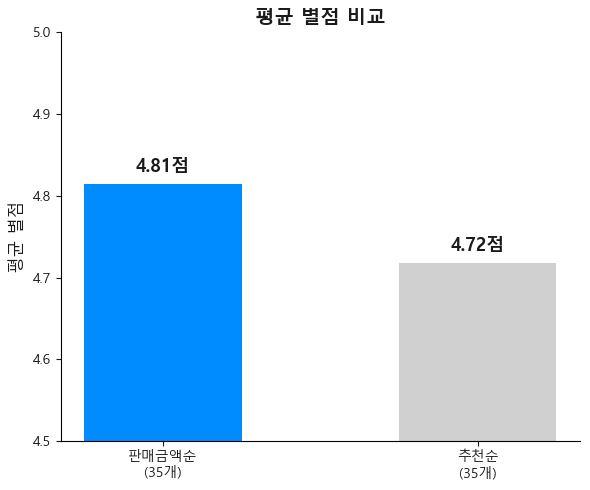

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

groups = ['판매금액순\n(35개)', '추천순\n(35개)']
grades = [df_only_sale['grade'].mean(), df_only_rec['grade'].mean()]
bars = ax.bar(groups, grades, color=[BLUE, GRAY], width=0.5)

for bar, val in zip(bars, grades):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}점', ha='center', va='bottom', fontsize=13, fontweight='bold', color=BLACK)

ax.set_title('평균 별점 비교', fontsize=14, fontweight='bold', color=BLACK)
ax.set_ylim(4.5, 5.0)
ax.set_ylabel('평균 별점', fontsize=12, color=BLACK)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=BLACK)

plt.tight_layout()
plt.show()

### 카테고리 분포 비교

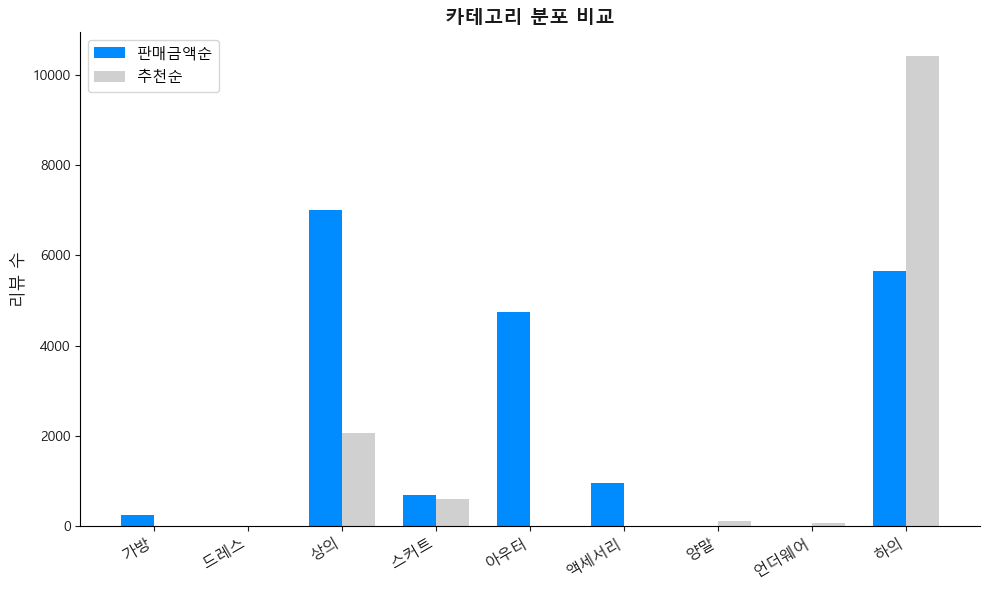

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

all_cats = sorted(set(df_only_sale['category'].unique()) | set(df_only_rec['category'].unique()))
sale_cat = df_only_sale['category'].value_counts().reindex(all_cats, fill_value=0)
rec_cat = df_only_rec['category'].value_counts().reindex(all_cats, fill_value=0)

x = np.arange(len(all_cats))
width = 0.35
ax.bar(x - width/2, sale_cat, width, label='판매금액순', color=BLUE)
ax.bar(x + width/2, rec_cat, width, label='추천순', color=GRAY)

ax.set_title('카테고리 분포 비교', fontsize=14, fontweight='bold', color=BLACK)
ax.set_xticks(x)
ax.set_xticklabels(all_cats, fontsize=11, rotation=30, ha='right', color=BLACK)
ax.set_ylabel('리뷰 수', fontsize=12, color=BLACK)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=BLACK)

plt.tight_layout()
plt.show()

### 사이즈 피드백 비교

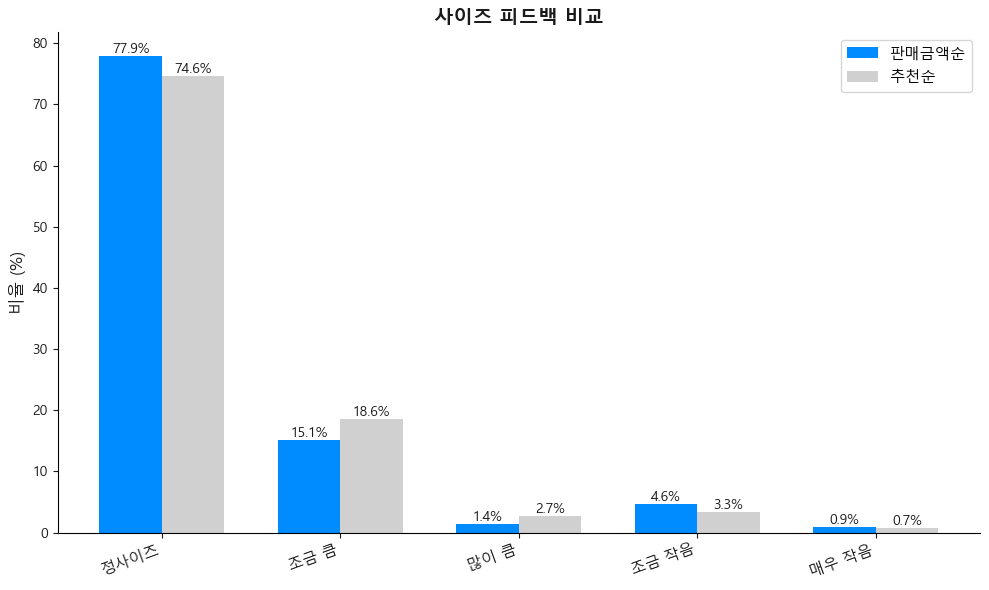

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

feedback_order = ['정사이즈', '조금 큼', '많이 큼', '조금 작음', '매우 작음']
sale_fb = df_only_sale['size_feedback'].value_counts(normalize=True).reindex(feedback_order, fill_value=0) * 100
rec_fb = df_only_rec['size_feedback'].value_counts(normalize=True).reindex(feedback_order, fill_value=0) * 100

x = np.arange(len(feedback_order))
width = 0.35
ax.bar(x - width/2, sale_fb, width, label='판매금액순', color=BLUE)
ax.bar(x + width/2, rec_fb, width, label='추천순', color=GRAY)

for i, (s, r) in enumerate(zip(sale_fb, rec_fb)):
    ax.text(i - width/2, s + 0.5, f'{s:.1f}%', ha='center', fontsize=10, color=BLACK)
    ax.text(i + width/2, r + 0.5, f'{r:.1f}%', ha='center', fontsize=10, color=BLACK)

ax.set_title('사이즈 피드백 비교', fontsize=14, fontweight='bold', color=BLACK)
ax.set_xticks(x)
ax.set_xticklabels(feedback_order, fontsize=11, rotation=20, ha='right', color=BLACK)
ax.set_ylabel('비율 (%)', fontsize=12, color=BLACK)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=BLACK)

plt.tight_layout()
plt.show()

---
① 평균 별점
판매금액순 4.81 vs 추천순 4.72 → 실제로 팔리는 상품이 더 높은 만족도         
② 카테고리
판매금액순 → 상의·아우터 강세 
추천순 → 하의 압도적 집중 (10,422건)
무신사가 하의를 밀고 있지만 고객은 상의·아우터를 더 많이 사고 만족함                   
③ 사이즈 피드백
추천순 "조금 큼" 18.6% > 판매금액순 15.1%
무신사가 추천하는 상품일수록 사이즈가 더 크게 느껴진다는 신호 → 핏/사이즈 괴리 근거

---

## 판매금액순 vs 무신사추천순 벤다이어그램

In [14]:
kiwi = Kiwi()

In [15]:
# 명사/형용사/동사 추출 함수
def extract_words(text):
    if not isinstance(text, str):
        return ""
    result = kiwi.analyze(text)
    tokens = []
    for token in result[0][0]:
        if token.tag in ('NNG', 'NNP', 'VA', 'VV') and len(token.form) > 1:
            tokens.append(token.form)
    return " ".join(tokens)

print("판매금액순 형태소 분석 중...")
sale_texts = df_sale['content_clean'].fillna("").apply(extract_words).tolist()
print("추천순 형태소 분석 중...")
rec_texts = df_rec['content_clean'].fillna("").apply(extract_words).tolist()
print("완료!")

판매금액순 형태소 분석 중...
추천순 형태소 분석 중...
완료!


In [16]:
# 불용어 정의
stopwords = ['있다', '없다', '같다', '하다', '되다', '이다', '않다', '좋다', '크다', '작다',
             '맞다', '오다', '가다', '보다', '주다', '받다', '입다', '사다', '나다', '싶다']

# 판매금액순 TF-IDF
vectorizer_sale = TfidfVectorizer(max_features=300, stop_words=stopwords)
tfidf_sale = vectorizer_sale.fit_transform(sale_texts)
sale_words = vectorizer_sale.get_feature_names_out()
sale_scores = np.array(tfidf_sale.sum(axis=0)).flatten()
sale_top = dict(zip(sale_words, sale_scores))
sale_top50_words = set(sorted(sale_top, key=sale_top.get, reverse=True)[:50])

# 추천순 TF-IDF
vectorizer_rec = TfidfVectorizer(max_features=300, stop_words=stopwords)
tfidf_rec = vectorizer_rec.fit_transform(rec_texts)
rec_words = vectorizer_rec.get_feature_names_out()
rec_scores = np.array(tfidf_rec.sum(axis=0)).flatten()
rec_top = dict(zip(rec_words, rec_scores))
rec_top50_words = set(sorted(rec_top, key=rec_top.get, reverse=True)[:50])

# 결과 확인
both = sale_top50_words & rec_top50_words
only_sale = sale_top50_words - rec_top50_words
only_rec = rec_top50_words - sale_top50_words

print(f"공통 키워드 ({len(both)}개): {both}")
print(f"\n판매금액순에만 있는 키워드 ({len(only_sale)}개): {only_sale}")
print(f"\n추천순에만 있는 키워드 ({len(only_rec)}개): {only_rec}")

공통 키워드 (41개): {'여름', '구매', '길이', '나오', '스타일', '가격', '재질', '소재', '예쁘', '사이즈', '보이', '이너', '기장', '색상', '무탠다드', '허리', '느낌', '어울리', '편하', '이쁘', '벨트', '괜찮', '디자인', '가을', '생각', '빠르', '매장', '다니', '바지', '신사', '기본', '배송', '만족', '주문', '추천', '가성비', '정도', '블랙', '원단', '마음', '두께'}

판매금액순에만 있는 키워드 (9개): {'대비', '최고', '오버핏', '늘어나', '고민', '퀄리티', '구입', '저렴하', '필요'}

추천순에만 있는 키워드 (9개): {'색감', '줄이', '슬랙스', '와이드', '다리', '수선', '신축', '부분', '겨울'}


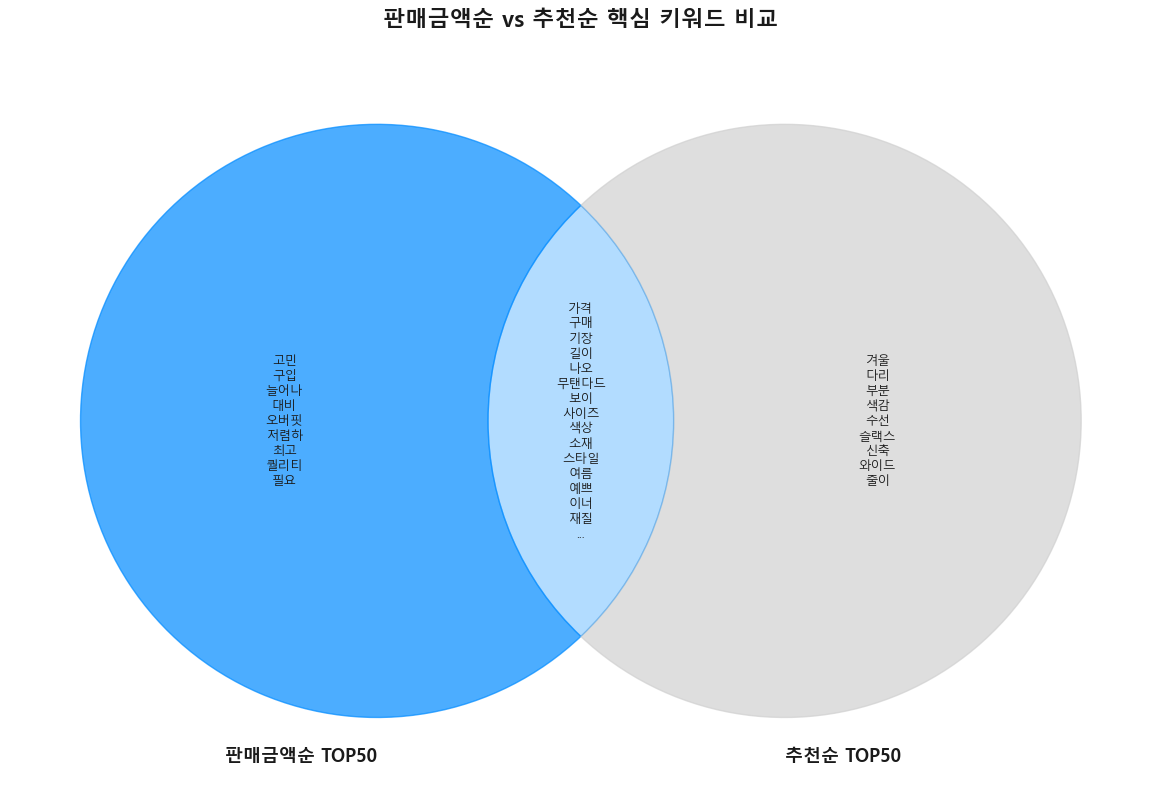

In [17]:
from matplotlib_venn import venn2

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

v = venn2(
    subsets=(20, 20, 5),
    set_labels=('판매금액순 TOP50', '추천순 TOP50'),
    ax=ax
)

# 색상 설정
v.get_patch_by_id('10').set_color(BLUE)
v.get_patch_by_id('10').set_alpha(0.7)
v.get_patch_by_id('01').set_color(GRAY)
v.get_patch_by_id('01').set_alpha(0.7)
v.get_patch_by_id('11').set_color(BLUE)
v.get_patch_by_id('11').set_alpha(0.3)

# 키워드 텍스트 설정
v.get_label_by_id('10').set_text('\n'.join(sorted(only_sale)))
v.get_label_by_id('01').set_text('\n'.join(sorted(only_rec)))
v.get_label_by_id('11').set_text('\n'.join(sorted(list(both)[:15])) + '\n...')

# 폰트 크기
for text in v.set_labels:
    text.set_fontsize(13)
    text.set_fontweight('bold')
    text.set_color(BLACK)
for text in v.subset_labels:
    if text:
        text.set_fontsize(9)
        text.set_color(BLACK)

ax.set_title('판매금액순 vs 추천순 핵심 키워드 비교',
             fontsize=16, fontweight='bold', color=BLACK, pad=20)

plt.tight_layout()
plt.show()

## 세그먼트 사분면으로 확인

In [18]:
# 핏 관련 키워드 목록
fit_keywords = ['핏', '허리', '기장', '길이', '크다', '작다', '오버핏', '통', '넓다', '좁다', '딱', '맞다', '여유']

# 군집별 핏 키워드 언급 비율 계산
def has_fit_keyword(text):
    if not isinstance(text, str):
        return False
    return any(kw in text for kw in fit_keywords)

df_cluster['has_fit_kw'] = df_cluster['content_clean'].apply(has_fit_keyword)

fit_pct = df_cluster.groupby('cluster')['has_fit_kw'].mean() * 100
print("군집별 핏 키워드 언급 비율:")
print(fit_pct)

군집별 핏 키워드 언급 비율:
cluster
0    33.633592
1    36.267428
2    73.880806
3    48.165555
Name: has_fit_kw, dtype: float64


In [21]:
# 군집별 지표
# x축: 핏 키워드 언급 비율 — 핏 민감도
# y축: 부정 감성 비율 — 전반적 불만 강도 (노트북 결과값)
# 버블 크기: 군집 리뷰 수

fit_pct_dict = fit_pct.to_dict()  # Cell 2에서 계산한 값

segment_data = {
    'persona': ['검증 구매형', '소재 목적형', '핏 기준형', '경험 만족형'],
    'cluster': [0, 1, 2, 3],
    'negative_pct': [3.7, 4.2, 10.7, 0.4],
    'fit_kw_pct': [fit_pct_dict[0], fit_pct_dict[1], fit_pct_dict[2], fit_pct_dict[3]],
    'count': [7216, 5953, 7148, 6596],
}

df_seg = pd.DataFrame(segment_data)
print(df_seg)

  persona  cluster  negative_pct  fit_kw_pct  count
0  검증 구매형        0           3.7   33.633592   7216
1  소재 목적형        1           4.2   36.267428   5953
2   핏 기준형        2          10.7   73.880806   7148
3  경험 만족형        3           0.4   48.165555   6596


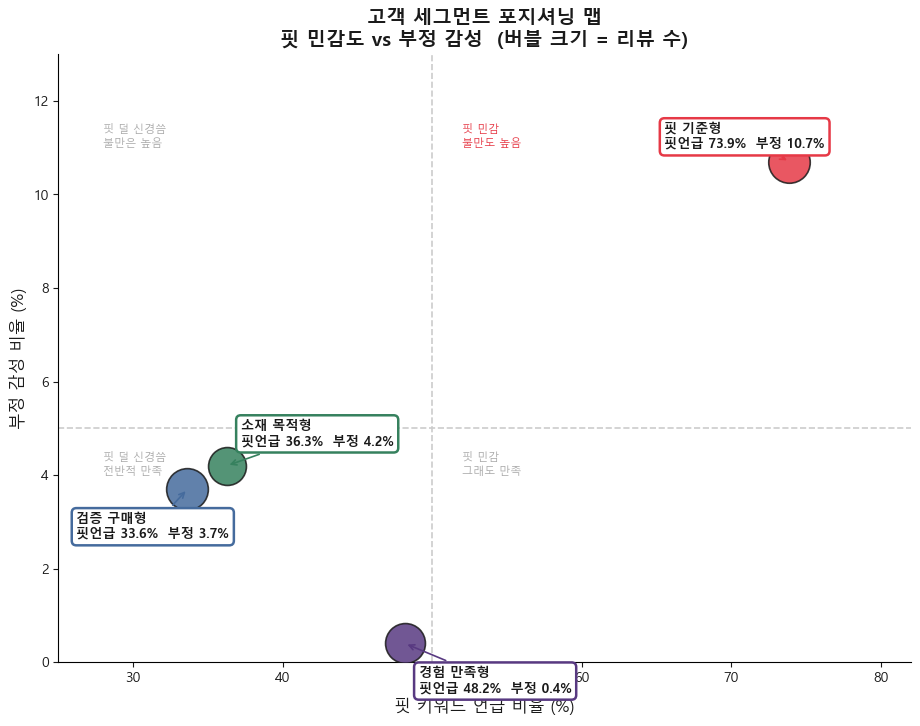

In [22]:
# 세그먼트 비교용 4색
SEG_COLORS = {
    '검증 구매형': '#456B9D',
    '소재 목적형': '#36815E',
    '핏 기준형':   '#E63946',
    '경험 만족형': '#583981',
}
colors = ['#456B9D', '#36815E', '#E63946', '#583981']  # cluster 0,1,2,3 순서

# 라벨 위치 수동 지정 (군집별로 다르게)
label_offsets = {
    0: (-80, -35),   # 검증 구매형 — 왼쪽 아래
    1: (10, 15),     # 소재 목적형 — 오른쪽 위
    2: (-90, 10),    # 핏 기준형 — 왼쪽
    3: (10, -35),    # 경험 만족형 — 오른쪽 아래
}

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

# 사분면 기준선 — 고정값
x_mid = 50
y_mid = 5

ax.axvline(x=x_mid, color='#CCCCCC', linewidth=1.2, linestyle='--', zorder=1)
ax.axhline(y=y_mid, color='#CCCCCC', linewidth=1.2, linestyle='--', zorder=1)

# 사분면 코너 라벨
ax.text(28,  11.5, '핏 덜 신경씀\n불만은 높음',  fontsize=8, color='#AAAAAA', va='top')
ax.text(52,  11.5, '핏 민감\n불만도 높음',       fontsize=8, color='#E63946', va='top')
ax.text(28,   4.5, '핏 덜 신경씀\n전반적 만족',  fontsize=8, color='#AAAAAA', va='top')
ax.text(52,   4.5, '핏 민감\n그래도 만족',       fontsize=8, color='#AAAAAA', va='top')

# 버블 + 라벨
for _, row in df_seg.iterrows():
    c = colors[int(row['cluster'])]
    ox, oy = label_offsets[int(row['cluster'])]

    ax.scatter(row['fit_kw_pct'], row['negative_pct'],
               s=row['count'] / 8, color=c, alpha=0.85,
               edgecolors=BLACK, linewidths=1.2, zorder=3)

    ax.annotate(
        f"{row['persona']}\n핏언급 {row['fit_kw_pct']:.1f}%  부정 {row['negative_pct']}%",
        xy=(row['fit_kw_pct'], row['negative_pct']),
        xytext=(ox, oy), textcoords='offset points',
        fontsize=9.5, fontweight='bold', color=BLACK,
        bbox=dict(boxstyle='round,pad=0.35', facecolor=WHITE,
                  edgecolor=c, linewidth=1.8),
        arrowprops=dict(arrowstyle='->', color=c, lw=1.2)
    )

ax.set_xlim(25, 82)
ax.set_ylim(0, 13)
ax.set_xlabel('핏 키워드 언급 비율 (%)', fontsize=12, color=BLACK, labelpad=10)
ax.set_ylabel('부정 감성 비율 (%)', fontsize=12, color=BLACK)
ax.set_title('고객 세그먼트 포지셔닝 맵\n핏 민감도 vs 부정 감성  (버블 크기 = 리뷰 수)',
             fontsize=14, fontweight='bold', color=BLACK)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors=BLACK)

plt.subplots_adjust(bottom=0.12)
plt.show()

### 세그먼트 비율 비교: 판매금액순 vs 추천순

| 페르소나 | 판매금액순 | 추천순 | 변화 |
|---|---|---|---|
| 검증 구매형 | 26.8% | 25.7% | ≈ 유사 |
| 소재 목적형 | 22.1% | 18.6% | ↓ -3.5%p |
| **핏 기준형** | **26.6%** | **30.9%** | **↑ +4.3%p** |
| 경험 만족형 | 24.5% | 24.8% | ≈ 유사 |

→ 무신사 추천 알고리즘이 미는 상품일수록 핏을 꼼꼼하게 따지는 고객 비율이 더 높음
→ 브랜드가 추천하는 상품과 소비자의 핏 기대치 사이 괴리가 더 크다는 신호

## 카테고리 × 세그먼트 부정감성 히트맵

In [31]:
# 카테고리 x 세그먼트 부정감성 비율 계산
heatmap_data = df_cluster.groupby(['category', 'persona'])['sentiment_score'].apply(
    lambda x: (x == 0).sum() / len(x) * 100
).unstack().round(1)

# 세그먼트 순서 고정 (새 이름)
persona_order = ['검증 구매형', '소재 목적형', '핏 기준형', '경험 만족형']
heatmap_data = heatmap_data.reindex(columns=persona_order)

# 카테고리 순서 — 리뷰 수 많은 순
cat_order = df_cluster.groupby('category').size().sort_values(ascending=False).index.tolist()
heatmap_data = heatmap_data.reindex(cat_order)

print(heatmap_data)

persona   검증 구매형  소재 목적형  핏 기준형  경험 만족형
category                               
하의           3.2     4.7    9.8     0.2
상의           5.1     4.3   13.7     0.5
아우터          2.9     3.5    8.7     0.6
액세서리         4.4     1.8   13.8     0.1
스커트          0.7     5.1    7.5     0.5
가방           2.3     0.0   11.8     0.0


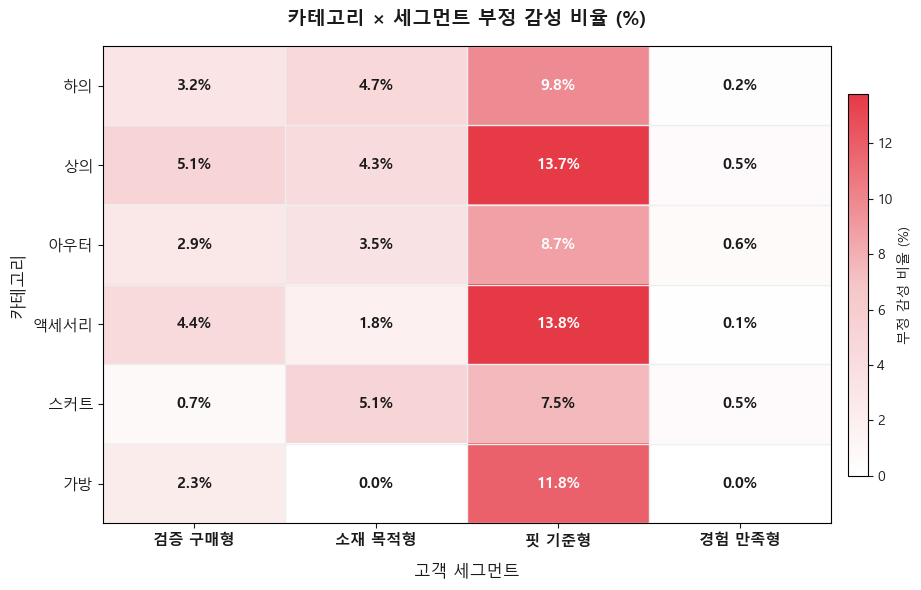

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['#FFFFFF', '#F5C6C8', '#E63946']
)

data = heatmap_data.values
im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=0, vmax=data.max())

# x축 — 세그먼트
ax.set_xticks(range(len(persona_order)))
ax.set_xticklabels(persona_order, fontsize=11, fontweight='bold', color=BLACK)

# y축 — 카테고리
ax.set_yticks(range(len(cat_order)))
ax.set_yticklabels(cat_order, fontsize=11, color=BLACK)

# x축 라벨에 세그먼트 색상 적용
seg_colors = ['#456B9D', '#36815E', '#E63946', '#583981']
for tick, color in zip(ax.get_xticklabels(), seg_colors):
    tick.set_color(color)

# 셀 안에 수치 표시
for i in range(len(cat_order)):
    for j in range(len(persona_order)):
        val = data[i, j]
        if np.isnan(val):
            text = '-'
            color = '#AAAAAA'
        else:
            text = f'{val:.1f}%'
            color = WHITE if val > data.max() * 0.6 else BLACK
        ax.text(j, i, text, ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

# 격자선
ax.set_xticks(np.arange(-0.5, len(persona_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(cat_order), 1), minor=True)
ax.grid(which='minor', color='#EEEEEE', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)

# 컬러바
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('부정 감성 비율 (%)', fontsize=10, color=BLACK)
cbar.ax.tick_params(colors=BLACK)

ax.set_title('카테고리 × 세그먼트 부정 감성 비율 (%)',
             fontsize=14, fontweight='bold', color=BLACK, pad=15)
ax.set_xlabel('고객 세그먼트', fontsize=12, color=BLACK, labelpad=10)
ax.set_ylabel('카테고리', fontsize=12, color=BLACK)
ax.tick_params(colors=BLACK, top=False, bottom=True)

plt.tight_layout()
plt.show()

## 세그먼트 비율 확인

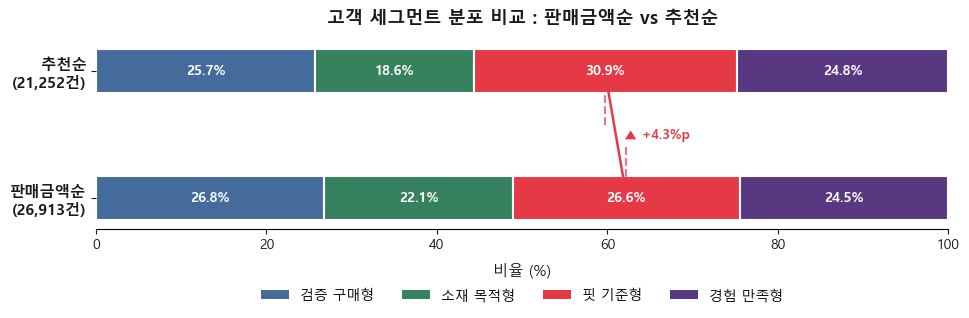

In [41]:
# 데이터
labels = ['판매금액순\n(26,913건)', '추천순\n(21,252건)']

sale_pcts = [26.8, 22.1, 26.6, 24.5]
rec_pcts  = [25.7, 18.6, 30.9, 24.8]

persona_names = ['검증 구매형', '소재 목적형', '핏 기준형', '경험 만족형']
seg_colors    = ['#456B9D', '#36815E', '#E63946', '#583981']

fig, ax = plt.subplots(figsize=(11, 3))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

data = [sale_pcts, rec_pcts]

for row_idx, (row_label, row_data) in enumerate(zip(labels, data)):
    left = 0
    for col_idx, (val, color, name) in enumerate(zip(row_data, seg_colors, persona_names)):
        ax.barh(row_idx, val, left=left, color=color,
                edgecolor=WHITE, linewidth=1.5, height=0.35)

        if val >= 4:
            ax.text(left + val / 2, row_idx, f'{val}%',
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color=WHITE)
        left += val

# y축
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=11, fontweight='bold', color=BLACK)

# x축
ax.set_xlim(0, 100)
ax.set_xlabel('비율 (%)', fontsize=11, color=BLACK, labelpad=8)
ax.tick_params(colors=BLACK)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# 핏 기준형 변화 강조 — 세로 점선 + 차이 텍스트
fit_sale_mid = 26.8 + 22.1 + 26.6 / 2   # 판매금액순 핏기준형 중심
fit_rec_mid  = 25.7 + 18.6 + 30.9 / 2   # 추천순 핏기준형 중심

ax.axvline(x=fit_sale_mid, ymin=0.1, ymax=0.45,
           color='#E63946', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(x=fit_rec_mid, ymin=0.55, ymax=0.9,
           color='#E63946', linewidth=1.5, linestyle='--', alpha=0.7)

ax.annotate('', xy=(fit_rec_mid, 0.82), xytext=(fit_sale_mid, 0.18),
            xycoords=('data', 'axes fraction'),
            textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle='<->', color='#E63946', lw=1.8))

ax.text((fit_sale_mid + fit_rec_mid) / 2 + 1, 0.5,
        '▲ +4.3%p',
        transform=ax.get_xaxis_transform(),
        fontsize=9.5, color='#E63946', fontweight='bold', va='center')

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=c, label=n)
    for c, n in zip(seg_colors, persona_names)
]
ax.legend(handles=legend_elements, fontsize=10,
          loc='upper center', bbox_to_anchor=(0.5, -0.25),
          ncol=4, frameon=False)

ax.set_title('고객 세그먼트 분포 비교 : 판매금액순 vs 추천순',
             fontsize=13, fontweight='bold', color=BLACK, pad=12)

plt.subplots_adjust(bottom=0.25)
plt.show()

# 보고서 가설 검정

In [23]:
# 상품 단위 중복 제거
sale_top50 = df_sale.groupby(['goods_no', 'goods_name', 'category', 'sale_price', 'sale_rate', 'review_count', 'review_score']).size().reset_index(name='_').drop(columns='_')
rec_top50  = df_rec.groupby(['goods_no', 'goods_name', 'category', 'sale_price', 'sale_rate', 'review_count', 'review_score']).size().reset_index(name='_').drop(columns='_')

# 세 집단 분리
overlap_ids   = set(sale_top50['goods_no']) & set(rec_top50['goods_no'])
only_sale_ids = set(sale_top50['goods_no']) - set(rec_top50['goods_no'])
only_rec_ids  = set(rec_top50['goods_no'])  - set(sale_top50['goods_no'])

df_common    = sale_top50[sale_top50['goods_no'].isin(overlap_ids)].copy()
df_only_sale = sale_top50[sale_top50['goods_no'].isin(only_sale_ids)].copy()
df_only_rec  = rec_top50[rec_top50['goods_no'].isin(only_rec_ids)].copy()

df_common['group']    = '공통 (15개)'
df_only_sale['group'] = '판매금액순 단독 (35개)'
df_only_rec['group']  = '추천순 단독 (35개)'

df_all = pd.concat([df_common, df_only_sale, df_only_rec], ignore_index=True)

# Jaccard similarity
jaccard = len(overlap_ids) / (len(sale_top50) + len(rec_top50) - len(overlap_ids))
print(f"Jaccard Similarity: {jaccard:.3f} ({jaccard*100:.1f}%)")
print(f"교집합: {len(overlap_ids)}개 | 판매단독: {len(only_sale_ids)}개 | 추천단독: {len(only_rec_ids)}개")

# 집단별 평균 비교
summary = df_all.groupby('group')[['sale_price', 'review_count', 'review_score']].mean().round(1)
summary.columns = ['평균 가격 (원)', '평균 리뷰 수', '평균 평점']
print()
print(summary)

Jaccard Similarity: 0.176 (17.6%)
교집합: 15개 | 판매단독: 35개 | 추천단독: 35개

                평균 가격 (원)  평균 리뷰 수  평균 평점
group                                    
공통 (15개)          41712.7   1800.5   96.7
추천순 단독 (35개)      36349.4    740.1   95.0
판매금액순 단독 (35개)    51909.1   2999.1   97.3


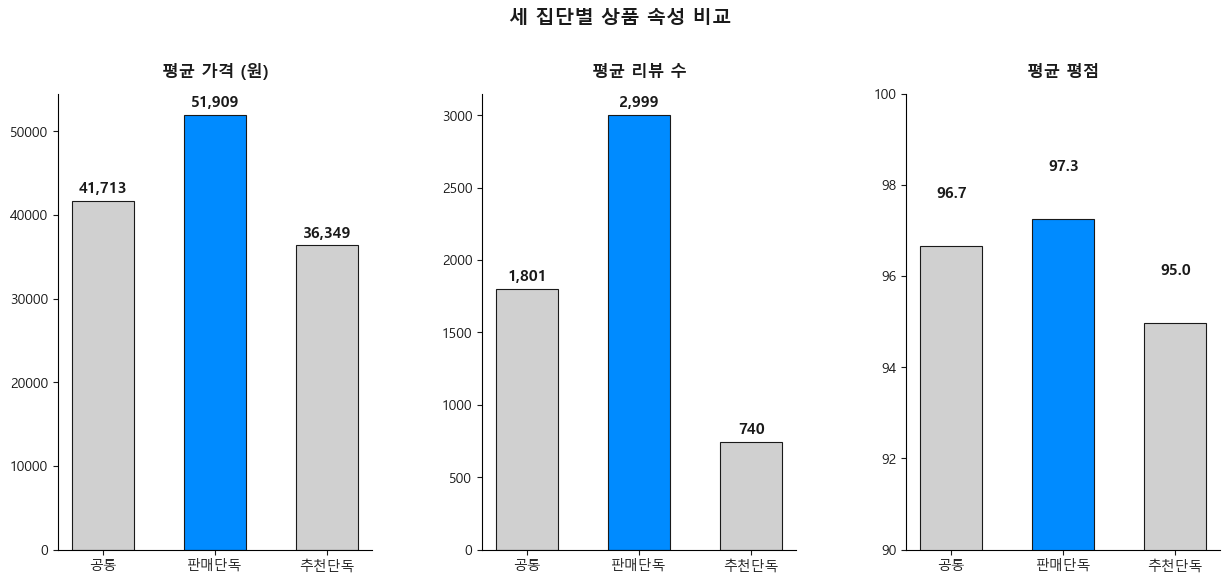

In [24]:
groups       = ['공통 (15개)', '판매금액순 단독 (35개)', '추천순 단독 (35개)']
group_colors = [GRAY, BLUE, GRAY]

metrics = [
    ('sale_price',    '평균 가격 (원)',  None),
    ('review_count',  '평균 리뷰 수',   None),
    ('review_score',  '평균 평점',      [90, 100]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor(WHITE)

for ax, (col, title, ylim) in zip(axes, metrics):
    ax.set_facecolor(WHITE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors=BLACK)

    vals = [df_all[df_all['group'] == g][col].mean() for g in groups]
    bars = ax.bar(range(3), vals, color=group_colors, width=0.55,
                  edgecolor=BLACK, linewidth=0.8)

    for bar, val in zip(bars, vals):
        label = f'{val:,.0f}' if col != 'review_score' else f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=BLACK)

    ax.set_xticks(range(3))
    ax.set_xticklabels(['공통', '판매단독', '추천단독'], fontsize=10, color=BLACK)
    ax.set_title(title, fontsize=12, fontweight='bold', color=BLACK, pad=12)

    if ylim:
        ax.set_ylim(ylim)

plt.suptitle('세 집단별 상품 속성 비교', fontsize=14, fontweight='bold', color=BLACK, y=1.02)
plt.subplots_adjust(wspace=0.35, bottom=0.12)
plt.show()

In [25]:
from scipy import stats

# 세 집단 분리
price_sale = df_only_sale['sale_price'].values
price_rec  = df_only_rec['sale_price'].values

review_sale = df_only_sale['review_count'].values
review_rec  = df_only_rec['review_count'].values

score_sale = df_only_sale['review_score'].values
score_rec  = df_only_rec['review_score'].values

# Mann-Whitney U 검정 (비모수, 소표본에 적합)
# 정규성 가정 어렵고 n=35로 작으므로 Mann-Whitney 사용

print("=== Mann-Whitney U 검정 (판매단독 vs 추천단독) ===\n")

for label, a, b in [
    ('가격',   price_sale,  price_rec),
    ('리뷰 수', review_sale, review_rec),
    ('평점',   score_sale,  score_rec),
]:
    stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    sig = "✅ 유의 (p<0.05)" if p < 0.05 else "❌ 비유의"
    print(f"[{label}]")
    print(f"  판매단독 중앙값: {int(np.median(a)):,} / 추천단독 중앙값: {int(np.median(b)):,}")
    print(f"  U통계량: {stat:.1f}, p-value: {p:.4f} → {sig}")
    print()

# Jaccard
overlap_ids   = set(sale_top50['goods_no']) & set(rec_top50['goods_no'])
jaccard = len(overlap_ids) / (len(sale_top50) + len(rec_top50) - len(overlap_ids))
print(f"=== Jaccard Similarity ===")
print(f"  교집합: {len(overlap_ids)}개 / 합집합: {len(sale_top50)+len(rec_top50)-len(overlap_ids)}개")
print(f"  Jaccard: {jaccard:.3f} ({jaccard*100:.1f}%)")

=== Mann-Whitney U 검정 (판매단독 vs 추천단독) ===

[가격]
  판매단독 중앙값: 49,900 / 추천단독 중앙값: 37,430
  U통계량: 827.5, p-value: 0.0116 → ✅ 유의 (p<0.05)

[리뷰 수]
  판매단독 중앙값: 691 / 추천단독 중앙값: 118
  U통계량: 831.5, p-value: 0.0103 → ✅ 유의 (p<0.05)

[평점]
  판매단독 중앙값: 98 / 추천단독 중앙값: 96
  U통계량: 904.0, p-value: 0.0003 → ✅ 유의 (p<0.05)

=== Jaccard Similarity ===
  교집합: 15개 / 합집합: 85개
  Jaccard: 0.176 (17.6%)
